# Stage 2 & 3 (S2/S3) — Ternary ResNet18 Student, KD + QAT

**Task 2:** build a ResNet18 whose conv/FC weights inside the residual blocks are constrained to $W_q \in \{-\alpha, 0, +\alpha\}$, with latent FP32 weights maintained separately from the quantized forward weights (`src/ternary.py`).

**Task 3:** train that student with a combined KD + QAT objective: the **frozen** ResNet34 teacher supplies temperature-scaled soft targets, while every forward pass genuinely uses the ternary weights.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


In [2]:
from src.data import get_cifar10_loaders, get_train_eval_loader

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)
train_eval_loader = get_train_eval_loader(data_dir="../data", batch_size=256)


## Load the frozen teacher
Loaded from the checkpoint produced by Notebook 01. The teacher is put in `eval()` mode and every parameter's `requires_grad` is set to `False` — no gradient can flow into it during student training.

In [3]:
from src.resnet_cifar import resnet34_cifar
from src.config import StudentKDQATConfig

student_cfg = StudentKDQATConfig()

teacher = resnet34_cifar(num_classes=10)
teacher_ckpt = torch.load(student_cfg.teacher_checkpoint, map_location=device)
teacher.load_state_dict(teacher_ckpt["model_state_dict"])
teacher.to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

print(f"Loaded teacher from epoch {teacher_ckpt['epoch']}, "
      f"val_acc={teacher_ckpt['val_acc']:.2f}%")


Loaded teacher from epoch 147, val_acc=95.50%


## Build the ternary student
Same `resnet18_cifar` builder as the FP32 baseline, but with `TernaryConv2d` / `TernaryLinear` injected for every conv/FC layer inside the residual blocks (stem + classifier head kept FP32 — see README for the justification).

In [4]:
from src.resnet_cifar import resnet18_cifar
from src.ternary import TernaryConv2d, TernaryLinear, verify_ternary_constraint
from src.utils import count_parameters

student = resnet18_cifar(
    num_classes=10,
    conv_layer=TernaryConv2d,
    linear_layer=TernaryLinear,
    first_last_fp32=True,
)
print(f"Total student parameters: {count_parameters(student):,}")

# Sanity check BEFORE training: every ternary layer's forward weight should
# already satisfy the ternary constraint (it's re-quantized on every forward
# call, so this holds for a freshly-initialized model too).
report = verify_ternary_constraint(student)
print(f"Ternary layers found: {len(report)} | all satisfy constraint: {all(report.values())}")


Total student parameters: 11,173,962
Ternary layers found: 19 | all satisfy constraint: True


## KD loss and training
$L = \lambda \, T^2 \, \mathrm{KL}\big(\mathrm{softmax}(z_t/T)\,\|\,\mathrm{softmax}(z_s/T)\big) + (1-\lambda)\,\mathrm{CE}(z_s, y)$

with $T$ = `temperature`, $\lambda$ = `kd_alpha` (see `src/kd_loss.py` for the full derivation and a worked numerical example). Training uses a short FP32 warmup (`fp32_warmup_epochs`) before switching on ternary quantization — progressive quantization for QAT stability.

In [5]:
from src.kd_loss import KDLoss
from src.train_kd_qat import train_kd_qat

kd_loss_fn = KDLoss(temperature=student_cfg.temperature,
                     alpha=student_cfg.kd_alpha,
                     label_smoothing=student_cfg.label_smoothing)

history, best_val_acc = train_kd_qat(
    student, teacher, train_loader, val_loader, device, student_cfg, kd_loss_fn
)
print(f"Best validation accuracy: {best_val_acc:.2f}%")


Epoch   1/160 | quant=OFF (warmup) | train_loss 1.3585 (kd 1.2302, hard 1.6579) acc 41.73% | val_loss 2.2075 acc 13.40%
Epoch   2/160 | quant=OFF (warmup) | train_loss 0.9069 (kd 0.8183, hard 1.1135) acc 63.33% | val_loss 2.0045 acc 18.42%
Epoch   3/160 | quant=OFF (warmup) | train_loss 0.6987 (kd 0.6268, hard 0.8666) acc 72.97% | val_loss 1.9119 acc 16.10%
Epoch   4/160 | quant=OFF (warmup) | train_loss 0.5904 (kd 0.5258, hard 0.7413) acc 77.58% | val_loss 2.0327 acc 12.46%
Epoch   5/160 | quant=OFF (warmup) | train_loss 0.5296 (kd 0.4686, hard 0.6720) acc 80.20% | val_loss 2.1384 acc 12.32%
Epoch   6/160 | quant=ON | train_loss 0.5330 (kd 0.4709, hard 0.6779) acc 79.98% | val_loss 0.6336 acc 74.38%
Epoch   7/160 | quant=ON | train_loss 0.4869 (kd 0.4275, hard 0.6256) acc 82.03% | val_loss 0.5670 acc 77.44%
Epoch   8/160 | quant=ON | train_loss 0.4529 (kd 0.3959, hard 0.5858) acc 83.33% | val_loss 0.5345 acc 78.50%
Epoch   9/160 | quant=ON | train_loss 0.4367 (kd 0.3810, hard 0.5667) 

Epoch  76/160 | quant=ON | train_loss 0.2248 (kd 0.1866, hard 0.3141) acc 92.46% | val_loss 0.2839 acc 88.52%
Epoch  77/160 | quant=ON | train_loss 0.2199 (kd 0.1818, hard 0.3087) acc 92.65% | val_loss 0.3140 acc 87.62%
Epoch  78/160 | quant=ON | train_loss 0.2232 (kd 0.1848, hard 0.3129) acc 92.52% | val_loss 0.2938 acc 88.02%
Epoch  79/160 | quant=ON | train_loss 0.2198 (kd 0.1817, hard 0.3088) acc 92.60% | val_loss 0.3176 acc 87.42%
Epoch  80/160 | quant=ON | train_loss 0.2147 (kd 0.1768, hard 0.3029) acc 92.92% | val_loss 0.2850 acc 88.18%
Epoch  81/160 | quant=ON | train_loss 0.2142 (kd 0.1767, hard 0.3017) acc 92.86% | val_loss 0.2751 acc 88.78%
Epoch  82/160 | quant=ON | train_loss 0.2120 (kd 0.1745, hard 0.2996) acc 92.97% | val_loss 0.3119 acc 87.68%
Epoch  83/160 | quant=ON | train_loss 0.2092 (kd 0.1719, hard 0.2961) acc 93.04% | val_loss 0.3483 acc 86.40%
Epoch  84/160 | quant=ON | train_loss 0.2029 (kd 0.1665, hard 0.2878) acc 93.25% | val_loss 0.2669 acc 89.24%
Epoch  85/

Epoch 151/160 | quant=ON | train_loss 0.0304 (kd 0.0070, hard 0.0850) acc 99.96% | val_loss 0.1306 acc 94.88%
Epoch 152/160 | quant=ON | train_loss 0.0303 (kd 0.0070, hard 0.0847) acc 99.96% | val_loss 0.1304 acc 95.00%
Epoch 153/160 | quant=ON | train_loss 0.0299 (kd 0.0065, hard 0.0844) acc 99.97% | val_loss 0.1304 acc 94.96%
Epoch 154/160 | quant=ON | train_loss 0.0299 (kd 0.0066, hard 0.0844) acc 99.98% | val_loss 0.1305 acc 95.08%
Epoch 155/160 | quant=ON | train_loss 0.0300 (kd 0.0066, hard 0.0844) acc 99.98% | val_loss 0.1303 acc 95.04%
Epoch 156/160 | quant=ON | train_loss 0.0301 (kd 0.0067, hard 0.0847) acc 99.97% | val_loss 0.1304 acc 95.06%
Epoch 157/160 | quant=ON | train_loss 0.0299 (kd 0.0065, hard 0.0844) acc 99.98% | val_loss 0.1300 acc 94.96%
Epoch 158/160 | quant=ON | train_loss 0.0300 (kd 0.0066, hard 0.0846) acc 99.97% | val_loss 0.1296 acc 95.10%
Epoch 159/160 | quant=ON | train_loss 0.0299 (kd 0.0065, hard 0.0845) acc 99.98% | val_loss 0.1299 acc 95.04%
Epoch 160/

## Training curves (for the report)

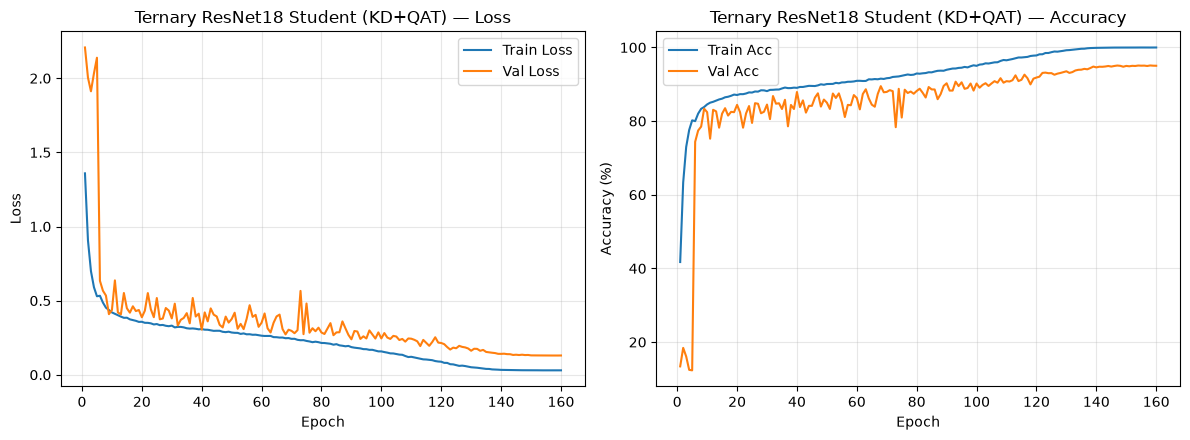

In [6]:
plot_training_curves(history, title="Ternary ResNet18 Student (KD+QAT)",
                      save_path=student_cfg.curve_plot_path)


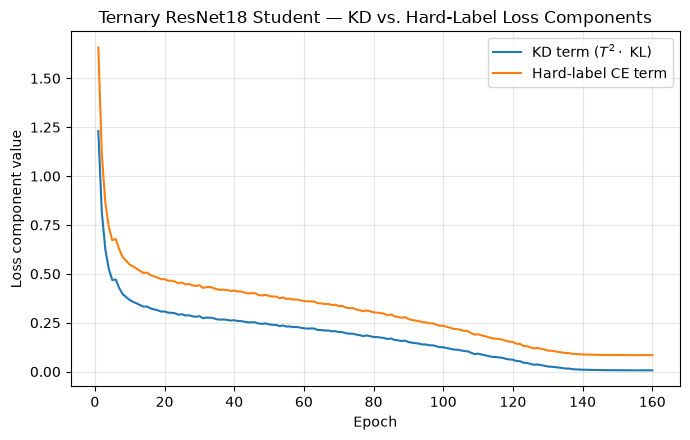

In [7]:
from src.utils import plot_kd_loss_breakdown

plot_kd_loss_breakdown(history, title="Ternary ResNet18 Student",
                        save_path=student_cfg.kd_breakdown_plot_path)


## Ternary-constraint verification on the SAVED checkpoint
Deliverable 3 requires "the script used to load and verify the ternary constraint on the saved weights" — this cell IS that script.

In [8]:
from src.evaluate import checkpoint_verification_report

best_ckpt = torch.load(student_cfg.checkpoint_path, map_location=device)
student.load_state_dict(best_ckpt["model_state_dict"])
student.to(device)

verification_df = checkpoint_verification_report(student)
print(verification_df.to_string(index=False))
print("\nAll layers satisfy the ternary constraint:",
      verification_df["Satisfies ternary constraint"].all())


                Layer  Satisfies ternary constraint
       layer1.0.conv1                          True
       layer1.0.conv2                          True
       layer1.1.conv1                          True
       layer1.1.conv2                          True
       layer2.0.conv1                          True
       layer2.0.conv2                          True
layer2.0.downsample.0                          True
       layer2.1.conv1                          True
       layer2.1.conv2                          True
       layer3.0.conv1                          True
       layer3.0.conv2                          True
layer3.0.downsample.0                          True
       layer3.1.conv1                          True
       layer3.1.conv2                          True
       layer4.0.conv1                          True
       layer4.0.conv2                          True
layer4.0.downsample.0                          True
       layer4.1.conv1                          True
       layer

In [9]:
from src.evaluate import evaluate_accuracy

train_acc = evaluate_accuracy(student, train_eval_loader, device)
test_acc = evaluate_accuracy(student, test_loader, device)
print(f"Best checkpoint epoch: {best_ckpt['epoch']}")
print(f"Train accuracy: {train_acc:.2f}%")
print(f"Val accuracy (at best epoch): {best_ckpt['val_acc']:.2f}%")
print(f"Test accuracy:  {test_acc:.2f}%")
print(f"Train-test gap: {train_acc - test_acc:.2f} pp")


Best checkpoint epoch: 158
Train accuracy: 99.49%
Val accuracy (at best epoch): 95.10%
Test accuracy:  94.63%
Train-test gap: 4.86 pp
